In [5]:
import pandas as pd
import collections
import plotnine as p9
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
import calcutta
reload(calcutta)

<module 'calcutta' from '/gpfs/commons/home/daknowles/calcutta/calcutta/calcutta.py'>

In [2]:
datadir = Path("/gpfs/commons/groups/knowles_lab/data/parse/original_SPLITseq_GSE110823/kallisto_joint/")
indexdir = Path("/gpfs/commons/groups/knowles_lab/index/kallisto/mus_musculus/with_precursor/")
count_file = datadir / "corrected100_sorted.txt.gz"

In [ ]:
1

In [ ]:
transcripts, t2g_dic = calcutta.get_transcript_gene_map(
    datadir / "transcripts.txt",
    indexdir / "transcripts_to_genes.txt")

In [243]:
transcript_lengths_dic = calcutta.get_transcript_lengths(indexdir / "Mus_musculus.GRCm38.cdna.all.fa")

assert(all([ a==b for a,b in zip(transcript_lengths_dic.keys(), transcripts) ]) )

In [180]:
transcript_lengths = np.array(list(transcript_lengths_dic.values())) # chatGPT says fragment size is 300 lol

In [3]:
ec_map = calcutta.read_ec(datadir / "matrix.ec")

Text(0.5, 0, 'log10(EC size)')

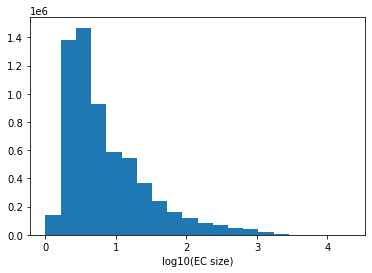

In [17]:
ec_sizes = [len(ec) for k,ec in ec_map.items()]
plt.hist(np.log10(ec_sizes),20)
plt.xlabel("log10(EC size)")

Check transcript count is consistent

In [183]:
len(transcripts)

118489

In [184]:
max(ec_reverse.keys())

118488

Check that number of EC is conistent

In [185]:
max(ec_map.keys()) 

533724

In [6]:
freq = calcutta.count_ECs_per_umi(count_file)
sum_freq = sum(freq.values())
x = range(1,31)
dat = pd.DataFrame({"x":x, "freq":[freq[i]/sum_freq for i in x]})
p9.ggplot(dat, p9.aes("x","freq",label="freq")) + p9.geom_text(format_string="{:.2g}") + p9.scale_y_log10() + p9.xlab("ECs per UMI")

KeyboardInterrupt: 

In [196]:
dat.head()

,x,freq
0,0,0.023171
1,1,0.808762
2,2,0.054550
3,3,0.024301
4,4,0.013504


4% of (BC,UMI) pairs have more than one EC. Will this still be the case for the full dataset? Depends how BCs are split across fastqs maybe? Also this is on the corrected data. Conclusion: yes it is. 

In [10]:
freq_transcript = calcutta.count_transcripts_per_umi(count_file, ec_map)

TypeError: 'int' object is not subscriptable

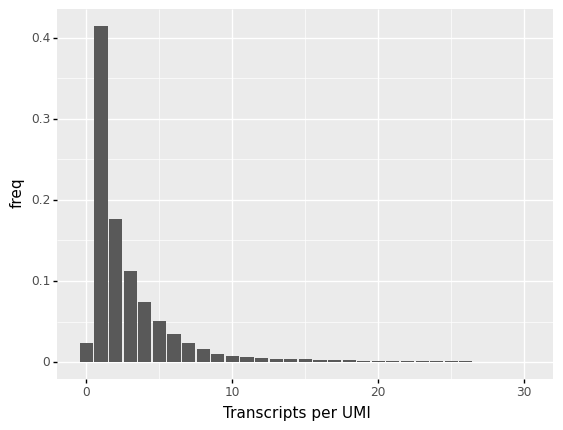

<ggplot: (8752505596808)>

In [191]:
sum_freq = sum(freq_transcript.values())
x = range(0,31)
dat = pd.DataFrame({"x":x, "freq":[freq_transcript[i]/sum_freq for i in x]})
p9.ggplot(dat, p9.aes("x","freq",label="freq")) + p9.geom_col() + p9.xlab("Transcripts per UMI")

This is actually surprising to me that 42% of UMIs map to a single transcript, but I suppose that is good! 1.4% of UMIs map to an inconsistent set of transcripts. 

In [192]:
freq_genes = calcutta.count_genes_per_umi(count_file)

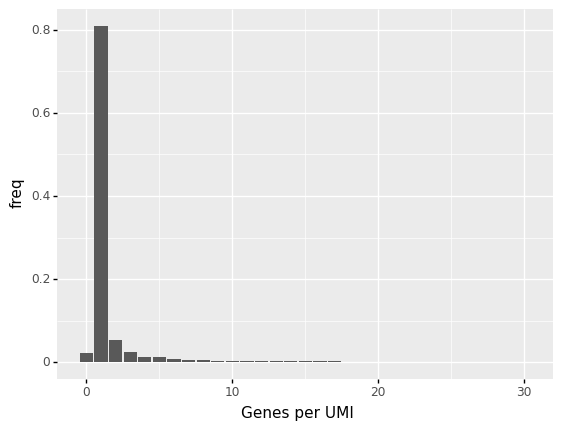

<ggplot: (8752429422026)>

In [193]:
sum_freq = sum(freq_genes.values())
x = range(0,31)
dat = pd.DataFrame({"x":x, "freq":[freq_genes[i]/sum_freq for i in x]})
p9.ggplot(dat, p9.aes("x","freq",label="freq")) + p9.geom_col() + p9.xlab("Genes per UMI")

In [194]:
dat.head()

,x,freq
0,0,0.023171
1,1,0.808762
2,2,0.054550
3,3,0.024301
4,4,0.013504


So over ~82% of UMIs align to a single gene at least. 

In [ ]:
import calcutta
reload(calcutta)
cell_ec, new_ec_map = calcutta.collapse_umis_per_cell_lowmem(count_file, ec_map) 

In [19]:
reverse_new_ec = { i:ec for ec,i in new_ec_map.items() }

In [10]:
len(new_ec_map)

2648087

Text(0.5, 0, 'log10(EC size)')

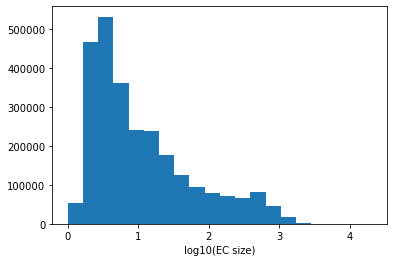

In [13]:
ec_sizes = np.array([len(ec) for ec,idx in new_ec_map.items()])
ec_sizes = ec_sizes[ec_sizes>0]
plt.hist(np.log10(ec_sizes),20)
plt.xlabel("log10(EC size)")

In [9]:
len(cell_ec)

564814

In [14]:
cell_depth = {bc : sum(g.values()) for bc,g in cell_ec.items() }

145.0

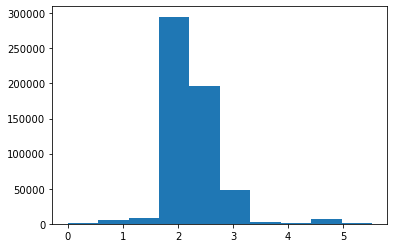

In [15]:
cell_depth_np = np.array(list(cell_depth.values()))

plt.hist(np.log10(cell_depth_np)) # 50-100 is range
np.median(cell_depth_np) # 145. This is without combining poly-dT and random hexamer primers
# 115 without mapping to precursor.

In [201]:
new_ec_map

(144454,)

Filter for cells with >=10 UMIs. 

In [16]:
cell_ec_sub = {bc:g for bc,g in cell_ec.items() if sum(g.values())>=10}

In [18]:
ec_counter = collections.Counter()
for bc,dic in cell_ec_sub.items(): 
    for ec in dic:
        ec_counter[ec] += 1

In [20]:
size_dist = collections.Counter()
for ec,count in ec_counter.items():
    size_dist[len(reverse_new_ec[ec])] += count

/gpfs/commons/home/daknowles/.conda/envs/asb/lib/python3.8/site-packages/pandas/core/arraylike.py:364: RuntimeWarning: divide by zero encountered in log10


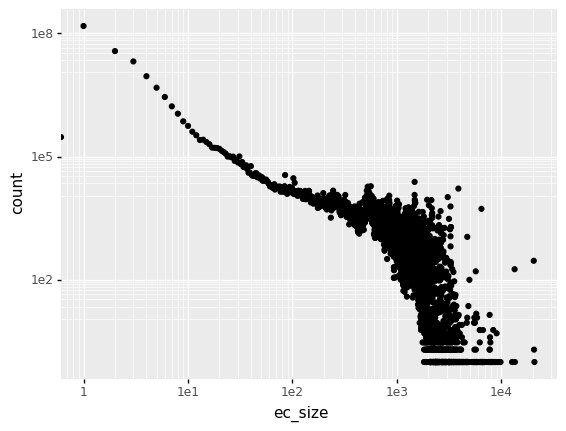

<ggplot: (8750614272600)>

In [27]:
size_dist_df = pd.DataFrame({"ec_size" : size_dist.keys(), "count" : size_dist.values()})
p9.ggplot(size_dist_df, p9.aes("ec_size", "count")) + p9.geom_point() + p9.scale_x_log10() + p9.scale_y_log10()

In [141]:
polydT_hex_pairs = pd.read_csv("alevin_pipeline/oligo_hex_bc_mapping.txt", sep = "\t" )
polydT_hex_pairs.columns = ["polydT", "hex"]
polydT_hex_pairs.head()

FileNotFoundError: [Errno 2] No such file or directory: 'alevin_pipeline/oligo_hex_bc_mapping.txt'

In [35]:
polydT_to_hex = { p:h for p,h in zip(polydT_hex_pairs.polydT, polydT_hex_pairs.hex) }

{'AACGTGAT': 'GATAGACA',
 'AAACATCG': 'GCCACATA',
 'ATGCCTAA': 'GCGAGTAA',
 'AGTGGTCA': 'GCTAACGA',
 'ACCACTGT': 'GCTCGGTA',
 'ACATTGGC': 'GGAGAACA',
 'CAGATCTG': 'GGTGCGAA',
 'CATCAAGT': 'GTACGCAA',
 'CGCTGATC': 'GTCGTAGA',
 'ACAAGCTA': 'GTCTGTCA',
 'CTGTAGCC': 'GTGTTCTA',
 'AGTACAAG': 'TAGGATGA',
 'AACAACCA': 'TATCAGCA',
 'AACCGAGA': 'TCCGTCTA',
 'AACGCTTA': 'TCTTCACA',
 'AAGACGGA': 'TGAAGAGA',
 'AAGGTACA': 'TGGAACAA',
 'ACACAGAA': 'TGGCTTCA',
 'ACAGCAGA': 'TGGTGGTA',
 'ACCTCCAA': 'TTCACGCA',
 'ACGCTCGA': 'AACTCACC',
 'ACGTATCA': 'AAGAGATC',
 'ACTATGCA': 'AAGGACAC',
 'AGAGTCAA': 'AATCCGTC',
 'AGATCGCA': 'AATGTTGC',
 'AGCAGGAA': 'ACACGACC',
 'AGTCACTA': 'ACAGATTC',
 'ATCCTGTA': 'AGATGTAC',
 'ATTGAGGA': 'AGCACCTC',
 'CAACCACA': 'AGCCATGC',
 'GACTAGTA': 'AGGCTAAC',
 'CAATGGAA': 'ATAGCGAC',
 'CACTTCGA': 'ATCATTCC',
 'CAGCGTTA': 'ATTGGCTC',
 'CATACCAA': 'CAAGGAGC',
 'CCAGTTCA': 'CACCTTAC',
 'CCGAAGTA': 'CCATCCTC',
 'CCGTGAGA': 'CCGACAAC',
 'CCTCCTGA': 'CCTAATCC',
 'CGAACTTA': 'CCTCTATC',


In [90]:
round2_bcs = pd.read_csv("splitseqv1_meta/splitseqv1_round2_barcodes.txt", sep = "\t")
round2_bcs.Sequence

0     /5Phos/CATCGGCGTACGACTAACGTGATATCCACGTGCTTGAG
1     /5Phos/CATCGGCGTACGACTAAACATCGATCCACGTGCTTGAG
2     /5Phos/CATCGGCGTACGACTATGCCTAAATCCACGTGCTTGAG
3     /5Phos/CATCGGCGTACGACTAGTGGTCAATCCACGTGCTTGAG
4     /5Phos/CATCGGCGTACGACTACCACTGTATCCACGTGCTTGAG
                          ...                      
91    /5Phos/CATCGGCGTACGACTGAACAGGCATCCACGTGCTTGAG
92    /5Phos/CATCGGCGTACGACTGACAGTGCATCCACGTGCTTGAG
93    /5Phos/CATCGGCGTACGACTGAGTTAGCATCCACGTGCTTGAG
94    /5Phos/CATCGGCGTACGACTGATGAATCATCCACGTGCTTGAG
95    /5Phos/CATCGGCGTACGACTGCCAAGACATCCACGTGCTTGAG
Name: Sequence, Length: 96, dtype: object

In [62]:
def find_variable_positions(strings): # thanks ChatGPT! 
    """
    Finds the variable positions in a list of fixed-length strings.

    :param strings: A list of fixed-length strings.
    :return: A list of variable positions.
    """
    variable_positions = []
    for i in range(len(strings[0])):
        is_variable = False
        for string in strings:
            if string[i] != strings[0][i]:
                is_variable = True
                break
        if is_variable:
            variable_positions.append(i)
    return variable_positions

find_variable_positions(round2_bcs.Sequence)

[22, 23, 24, 25, 26, 27, 28, 29]

In [91]:
round2_bcs_var = [ s[22:30] for s in  round2_bcs.Sequence]
round2_bcs_var

['AACGTGAT',
 'AAACATCG',
 'ATGCCTAA',
 'AGTGGTCA',
 'ACCACTGT',
 'ACATTGGC',
 'CAGATCTG',
 'CATCAAGT',
 'CGCTGATC',
 'ACAAGCTA',
 'CTGTAGCC',
 'AGTACAAG',
 'AACAACCA',
 'AACCGAGA',
 'AACGCTTA',
 'AAGACGGA',
 'AAGGTACA',
 'ACACAGAA',
 'ACAGCAGA',
 'ACCTCCAA',
 'ACGCTCGA',
 'ACGTATCA',
 'ACTATGCA',
 'AGAGTCAA',
 'AGATCGCA',
 'AGCAGGAA',
 'AGTCACTA',
 'ATCCTGTA',
 'ATTGAGGA',
 'CAACCACA',
 'GACTAGTA',
 'CAATGGAA',
 'CACTTCGA',
 'CAGCGTTA',
 'CATACCAA',
 'CCAGTTCA',
 'CCGAAGTA',
 'CCGTGAGA',
 'CCTCCTGA',
 'CGAACTTA',
 'CGACTGGA',
 'CGCATACA',
 'CTCAATGA',
 'CTGAGCCA',
 'CTGGCATA',
 'GAATCTGA',
 'CAAGACTA',
 'GAGCTGAA',
 'GATAGACA',
 'GCCACATA',
 'GCGAGTAA',
 'GCTAACGA',
 'GCTCGGTA',
 'GGAGAACA',
 'GGTGCGAA',
 'GTACGCAA',
 'GTCGTAGA',
 'GTCTGTCA',
 'GTGTTCTA',
 'TAGGATGA',
 'TATCAGCA',
 'TCCGTCTA',
 'TCTTCACA',
 'TGAAGAGA',
 'TGGAACAA',
 'TGGCTTCA',
 'TGGTGGTA',
 'TTCACGCA',
 'AACTCACC',
 'AAGAGATC',
 'AAGGACAC',
 'AATCCGTC',
 'AATGTTGC',
 'ACACGACC',
 'ACAGATTC',
 'AGATGTAC',
 'AGCACCTC',

In [92]:
round3_bcs = pd.read_csv("splitseqv1_meta/splitseqv1_round3_barcodes.txt", sep = "\t")
find_variable_positions(round3_bcs.Sequence)

[40, 41, 42, 43, 44, 45, 46, 47]

In [93]:
round3_bcs_var = [ s[40:48] for s in  round3_bcs.Sequence]
round3_bcs_var

['AACGTGAT',
 'AAACATCG',
 'ATGCCTAA',
 'AGTGGTCA',
 'ACCACTGT',
 'ACATTGGC',
 'CAGATCTG',
 'CATCAAGT',
 'CGCTGATC',
 'ACAAGCTA',
 'CTGTAGCC',
 'AGTACAAG',
 'AACAACCA',
 'AACCGAGA',
 'AACGCTTA',
 'AAGACGGA',
 'AAGGTACA',
 'ACACAGAA',
 'ACAGCAGA',
 'ACCTCCAA',
 'ACGCTCGA',
 'ACGTATCA',
 'ACTATGCA',
 'AGAGTCAA',
 'AGATCGCA',
 'AGCAGGAA',
 'AGTCACTA',
 'ATCCTGTA',
 'ATTGAGGA',
 'CAACCACA',
 'GACTAGTA',
 'CAATGGAA',
 'CACTTCGA',
 'CAGCGTTA',
 'CATACCAA',
 'CCAGTTCA',
 'CCGAAGTA',
 'CCGTGAGA',
 'CCTCCTGA',
 'CGAACTTA',
 'CGACTGGA',
 'CGCATACA',
 'CTCAATGA',
 'CTGAGCCA',
 'CTGGCATA',
 'GAATCTGA',
 'CAAGACTA',
 'GAGCTGAA',
 'GATAGACA',
 'GCCACATA',
 'GCGAGTAA',
 'GCTAACGA',
 'GCTCGGTA',
 'GGAGAACA',
 'GGTGCGAA',
 'GTACGCAA',
 'GTCGTAGA',
 'GTCTGTCA',
 'GTGTTCTA',
 'TAGGATGA',
 'TATCAGCA',
 'TCCGTCTA',
 'TCTTCACA',
 'TGAAGAGA',
 'TGGAACAA',
 'TGGCTTCA',
 'TGGTGGTA',
 'TTCACGCA',
 'AACTCACC',
 'AAGAGATC',
 'AAGGACAC',
 'AATCCGTC',
 'AATGTTGC',
 'ACACGACC',
 'ACAGATTC',
 'AGATGTAC',
 'AGCACCTC',

[b'AAAAAAAAAAAAAAAAAAAAAAAA',
 b'AAAAAAAAAAAAAAAAAAAAAAAC',
 b'AAAAAAAAAAAAAAAAAAAAAAAG',
 b'AAAAAAAAAAAAAAAAAAAAAAAT',
 b'AAAAAAAAAAAAAAAAAAAAAACA',
 b'AAAAAAAAAAAAAAAAAAAAAATA',
 b'AAAAAAAAAAAAAAAAAAAAAATT',
 b'AAAAAAAAAAAAAAAAAAAAACAA',
 b'AAAAAAAAAAAAAAAAAAAAATAA',
 b'AAAAAAAAAAAAAAAAAAAACAAA',
 b'AAAAAAAAAAAAAAAAAAAACCAA',
 b'AAAAAAAAAAAAAAAAAAAATAAA',
 b'AAAAAAAAAAAAAAAAAAACAAAA',
 b'AAAAAAAAAAAAAAAAAAACCAAA',
 b'AAAAAAAAAAAAAAAAAAAGAAAA',
 b'AAAAAAAAAAAAAAAAAACAAAAA',
 b'AAAAAAAAAAAAAAAAAACAAAAG',
 b'AAAAAAAAAAAAAAAAAACAAACA',
 b'AAAAAAAAAAAAAAAAAACAAATA',
 b'AAAAAAAAAAAAAAAAAACAATAA',
 b'AAAAAAAAAAAAAAAAAACAATAG',
 b'AAAAAAAAAAAAAAAAAACACAAA',
 b'AAAAAAAAAAAAAAAAAACATAAA',
 b'AAAAAAAAAAAAAAAAAACCAAAA',
 b'AAAAAAAAAAAAAAAAAAGAAAAA',
 b'AAAAAAAAAAAAAAAAAAGAAATA',
 b'AAAAAAAAAAAAAAAAAAGAATAA',
 b'AAAAAAAAAAAAAAAAAAGCAAAA',
 b'AAAAAAAAAAAAAAAAAATAAAAA',
 b'AAAAAAAAAAAAAAAAAATAAATA',
 b'AAAAAAAAAAAAAAAAACAAAAAA',
 b'AAAAAAAAAAAAAAAAACCAAAAA',
 b'AAAAAAAAAAAAAAAAAGAAAAAA',
 b'AAAAAAA

In [123]:
first_bc_whitelist == set(round2_bcs_var) # true!
first_bc_whitelist == set(round3_bcs_var) # true! 

True

In [97]:
valid_counter = collections.Counter()
for bc in cell_ec_sub: 
    valid_counter[bc[8:16].decode() in round2_bcs_var] += 1 # best! thought it should be at the end!? 
valid_counter

Counter({False: 263736, True: 296112})

In [125]:
matches = {}
for offset in range(17):
    print(offset, end = "\r")
    valid_counter = collections.Counter()
    for bc in cell_ec_sub:
        valid_counter[ bc[offset:offset+8].decode() in first_bc_whitelist] += 1 
    matches[offset] = valid_counter[True]


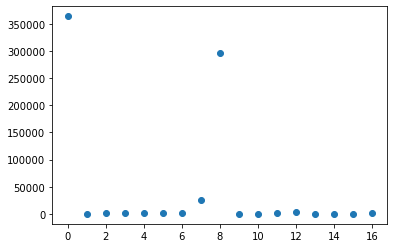

In [127]:
plt.scatter(matches.keys(), matches.values())

In [120]:

valid_counter = collections.Counter()
for bc in cell_ec_sub: 
    hit1 = bc[:8].decode() in first_bc_whitelist
    hit2 = bc[8:16].decode() in first_bc_whitelist
    valid_counter[ (hit1,hit2)] += 1 
valid_counter


Counter({(False, False): 96717,
         (False, True): 99361,
         (True, False): 167019,
         (True, True): 196751})

In [133]:
last_bc = []
for bc in cell_ec_sub: 
    hit1 = bc[:8].decode() in first_bc_whitelist
    hit2 = bc[8:16].decode() in first_bc_whitelist
    if hit1 and hit2: 
        last_bc.append(bc[16:])

196751

In [139]:
def count_frequency(strings):
    length = len(strings[0])
    freq = [collections.Counter() for _ in range(length)]
    for string in strings:
        for i, char in enumerate(string):
            freq[i][char] += 1
    return freq

count_frequency([g.decode() for g in last_bc])

[Counter({'A': 132412, 'G': 45489, 'T': 8475, 'C': 10375}),
 Counter({'G': 124403, 'C': 39794, 'A': 20345, 'T': 12209}),
 Counter({'C': 110927, 'A': 57423, 'G': 12234, 'T': 16167}),
 Counter({'A': 102678, 'T': 79342, 'C': 12687, 'G': 2044}),
 Counter({'T': 165800, 'A': 17458, 'C': 10525, 'G': 2968}),
 Counter({'T': 94717, 'C': 74815, 'A': 11382, 'G': 15837}),
 Counter({'A': 20723, 'C': 79435, 'G': 77790, 'T': 18803}),
 Counter({'G': 88359, 'A': 43591, 'T': 21919, 'C': 42882})]

In [140]:
count_frequency(round2_bcs_var)

[Counter({'A': 39, 'C': 29, 'G': 19, 'T': 9}),
 Counter({'A': 32, 'T': 16, 'G': 22, 'C': 26}),
 Counter({'C': 25, 'A': 26, 'G': 25, 'T': 20}),
 Counter({'G': 22, 'C': 25, 'A': 30, 'T': 19}),
 Counter({'T': 24, 'A': 25, 'C': 24, 'G': 23}),
 Counter({'G': 25, 'T': 25, 'C': 21, 'A': 25}),
 Counter({'A': 22, 'C': 23, 'G': 25, 'T': 26}),
 Counter({'T': 3, 'G': 3, 'A': 59, 'C': 31})]

In [118]:
#rc_bcs = {calcutta.reverse_complement(bc) for bc in first_bc_whitelist}
rc_bcs = { bc[::-1] for bc in first_bc_whitelist}

In [119]:
matches = {}
for offset in range(17):
    print(offset, end = "\r")
    valid_counter = collections.Counter()
    for bc in cell_ec_sub: 
        valid_counter[ bc[offset:offset+8].decode() in rc_bcs] += 1 
    matches[offset] = valid_counter[True]
matches

{0: 11794,
 1: 406,
 2: 1289,
 3: 2287,
 4: 1071,
 5: 2001,
 6: 1075,
 7: 5541,
 8: 10809,
 9: 250,
 10: 2883,
 11: 5593,
 12: 134,
 13: 23,
 14: 22,
 15: 20,
 16: 7452}

In [113]:
first_bc_whitelist == set(round2_bcs_var) # true, huh

True

In [71]:
first_bc_whitelist = set(polydT_hex_pairs.polydT).union(polydT_hex_pairs.hex) # len == 96
valid_counter = collections.Counter()
for bc in cell_ec_sub: 
    valid_counter[bc[:8].decode() in first_bc_whitelist] += 1 # best! thought it should be at the end!? 
valid_counter

Counter({False: 196078, True: 363770})

In [53]:
len(bc)

24

## Convert cell_ec into a sparse matrix

Sort by length then lowest id to put unambiguous ECs first

In [209]:
sorted_ecs, ec_id_map, sorted_BCs, indices, umi_counts = calcutta.cell_ec_to_sparse(cell_ec_sub)

In [213]:
len(sorted_BCs)

144454

In [ ]:
# np.save("uncorrected.npy", a, allow_pickle=False)
# np.savez("test.npz", a, allow_pickle=False) # this doesn't save any space

This is slow (5min?)! but does reduce from 2.3G to 0.3G! 

In [214]:
np.savez_compressed(
    "corrected.compressed.npz", 
    np.concatenate([indices, umi_counts[None,:]]), 
    allow_pickle=False) 

In [215]:
with open("corrected.ec","w") as f: 
    for g in sorted_ecs: 
        f.write(",".join([str(h) for h in g]) + "\n")